In [1]:
import os
import mne
import numpy as np
from mne.preprocessing import ICA
from typing import Dict, List, Optional
import matplotlib.pyplot as plt
mne.set_log_level('WARNING')

In [2]:
data_dir =  './raw/'
output_dir = './processed/'
subject_id = 1
hp_freq = 0.1
lp_freq = 40
target_sfreq = 250
epoch_tmin = -0.2
epoch_tmax = 0.8
artifact_threshold = 200e-6
ica_n_components = 20
ica_random_state = 42


montage = mne.channels.make_standard_montage('easycap-M1')

In [3]:
def _concatenate_events_with_offsets(
    event_list: list[np.ndarray],
    length_list: list[int],
) -> np.ndarray:
    """
    Concatenate per-session event arrays, adding cumulative sample offsets
    to column 0 (sample index) so indices are correct in the concatenated raw.

    Parameters
    ----------
    event_list  : list of (n_events, 3) arrays — one per session
    length_list : list of ints — n_times for each session raw, same order

    Returns
    -------
    np.ndarray of shape (total_events, 3) with corrected sample indices
    """
    adjusted = []
    offset = 0
    for events, length in zip(event_list, length_list):
        ev = events.copy()
        ev[:, 0] += offset   # shift sample indices by cumulative length
        adjusted.append(ev)
        offset += length
    return np.concatenate(adjusted, axis=0)

In [ ]:
def load_raw_eeg(subject_id: int, data_dir: str, num_sessions: int = 4) -> Dict[str, Dict[str, List[mne.io.RawArray, np.ndarray]]]:
    '''
    Load raw EEG data and events for a given subject across multiple sessions.
    
    Parameters
    ----------
    subject_id : int
        The ID of the subject for whom to load data.
    data_dir : str
        The directory containing the subject's data.
    num_sessions : int, optional
        The number of sessions to load (default is 4).

    Returns
    -------
    split_data : dict
        A dictionary with keys 'train' and 'test', each containing:
        - 'raw_eeg': an mne.io.RawArray object with concatenated EEG data
        - 'events': a numpy array of shape (n_events, 3) with event information
    '''
    split_session_data = {
        'train': {'raw_eeg': [], 'lengths': []},
        'test':  {'raw_eeg': [], 'lengths': []},
    }
    split_data = {
        'train': {'raw_eeg': None, 'events': []},
        'test':  {'raw_eeg': None, 'events': []},
    }
    channel_names = None

    channel_names = None
    

    for session in range(1, num_sessions + 1):
        fpath = os.path.join(data_dir, f'sub-{subject_id:02}', f'sub-{subject_id:02}', f'ses-{session:02}')
        train_data = np.load(os.path.join(fpath, 'raw_eeg_training.npy'), allow_pickle=True).item()
        test_data = np.load(os.path.join(fpath, 'raw_eeg_test.npy'), allow_pickle=True).item()

        if channel_names is None:
            channel_names = train_data['ch_names']
            channel_types = train_data['ch_types']
            sfreq = train_data['sfreq']
        
        train_eeg = train_data['raw_eeg_data']
        test_eeg = test_data['raw_eeg_data']

        info = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types=channel_types)
        train_raw = mne.io.RawArray(train_eeg, info)
        test_raw = mne.io.RawArray(test_eeg, info)

        del train_eeg, test_eeg, train_data, test_data
        
        train_events = mne.find_events(train_raw, stim_channel='stim')
        test_events = mne.find_events(test_raw, stim_channel='stim')
        # event structure: [sample_idx, 0, event_code]

        # print(f"{train_events.shape} training events")

        # reject target trials
        idx_target_train = np.where(train_events[:, 2] == 99999)[0]
        idx_target_test = np.where(test_events[:, 2] == 99999)[0]
        train_events = np.delete(train_events, idx_target_train, axis=0)
        test_events = np.delete(test_events, idx_target_test, axis=0)

        split_session_data['train']['raw_eeg'].append(train_raw)
        split_session_data['train']['lengths'].append(train_raw.n_times) 
        split_session_data['test']['raw_eeg'].append(test_raw)
        split_session_data['test']['lengths'].append(test_raw.n_times)
        split_data['train']['events'].append(train_events)
        split_data['test']['events'].append(test_events)



    for split in ['train', 'test']:
        split_data[split]['raw_eeg'] =  mne.concatenate_raws(split_session_data[split]['raw_eeg'])
        split_data[split]['events'] = _concatenate_events_with_offsets(
            split_data[split]['events'],
            split_session_data[split]['lengths'],
        )

   
    print(f"Subject {subject_id}: Loaded raw EEG data and events.")
    return split_data

      
# filtering raw eeg function
def filter_raw(raw: mne.io.Raw, hp_freq: float, lp_freq: float) -> mne.io.Raw:
    '''
    Apply a bandpass filter to the raw EEG data.
    
    Parameters
    ----------
    raw     : mne.io.Raw — the raw EEG data to filter
    hp_freq : float — high-pass cutoff frequency in Hz (e.g., 0.1)
    lp_freq : float — low-pass cutoff frequency in Hz (e.g., 40)

    Returns
    -------
    mne.io.Raw — the filtered raw EEG data (in-place modification)
    
    '''
    print(f"Applying bandpass filter: {hp_freq} {f' - {lp_freq}' if lp_freq else ''} Hz")
    raw.filter(
        l_freq=hp_freq,
        h_freq=lp_freq,
        method='fir',
        fir_design='hamming',
        phase='zero',
        picks='eeg',
    )
    print(f"Filtering complete. sfreq={raw.info['sfreq']:.0f} Hz, shape={raw.get_data(picks='eeg').shape}")
    return raw



In [23]:

def downsample_raw(
    raw: mne.io.Raw,
    events: np.ndarray,
    target_sfreq: float = 250.0,
) -> tuple[mne.io.Raw, np.ndarray]:
    """
    Downsample continuous raw EEG and rescale event sample indices.

    Parameters
    ----------
    raw          : mne.io.Raw  — filtered continuous raw
    events       : np.ndarray  — (n_events, 3) at original sfreq
    target_sfreq : float       — target sampling rate in Hz (default 250)

    Returns
    -------
    raw    : mne.io.Raw   — downsampled in-place
    events : np.ndarray   — (n_events, 3) with col 0 rescaled to target_sfreq
    """
    original_sfreq = raw.info['sfreq']

    if original_sfreq == target_sfreq:
        print(f"  [downsample] Already at {target_sfreq:.0f} Hz, skipping")
        return raw, events

    scale = target_sfreq / original_sfreq
    n_before = raw.n_times

    raw.resample(target_sfreq, verbose=False)

    # Rescale event sample indices (col 0) to match new sfreq
    # cols 1 and 2 (prev event, event ID) are unchanged
    events = events.copy()
    events[:, 0] = np.round(events[:, 0] * scale).astype(int)

    print(f"  [downsample] {original_sfreq:.0f} -> {target_sfreq:.0f} Hz  "
          f"({n_before} -> {raw.n_times} samples)")
    return raw, events


def run_ica(
    raw: mne.io.Raw,
    n_components: int = 30,
    random_state: int = 42,
    fit_hp_freq: float = 1.0,
) -> mne.io.Raw:
    """
    Fit ICA on a 1 Hz high-pass filtered copy of raw, then apply the
    resulting component exclusions to the original (0.1 Hz filtered) raw.

    This two-pass approach is best practice: ICA decomposes more cleanly
    on 1 Hz filtered data (less slow drift), but we preserve the slow
    components (P3, LPC) in the analysis data by applying to 0.1 Hz raw.

    Parameters
    ----------
    raw           : mne.io.Raw — continuous raw EEG, already filtered at 0.1 Hz
    n_components  : int        — number of ICA components to compute (default 30)
                                 rule of thumb: <= n_channels - n_bad_channels
    random_state  : int        — random seed for reproducibility
    fit_hp_freq   : float      — high-pass cutoff for ICA fitting copy (default 1.0 Hz)

    Returns
    -------
    mne.io.Raw — original raw with artifact components removed in-place

    Notes
    -----
    - EOG and ECG components are identified automatically via channel
      correlation. Verify manually on first subject (see plot lines below).
    - ICA is fit on EEG channels only — stim channel is excluded.
    - If no EOG/ECG channel is present, mne falls back to finding the
      worst-correlated frontal EEG channel as a proxy — this is less
      reliable; check the scores plots.
    """

    # --- Step 1: Make a 1 Hz high-pass copy just for fitting ICA ---
    # Do NOT use this copy for analysis — only for decomposition
    print(f"  [ICA] Creating 1 Hz high-pass copy for fitting...")
    raw_for_ica = raw.copy().filter(
        l_freq=fit_hp_freq,
        h_freq=None,
        picks='eeg',
        method='iir',
        iir_params=dict(order=4, ftype='butter'),
        verbose=False,
    )

    # --- Step 2: Fit ICA on the 1 Hz copy ---
    print(f"  [ICA] Fitting ICA with {n_components} components...")
    ica = ICA(
        n_components=n_components,
        method='fastica',
        random_state=random_state,
        max_iter=800,
    )
    ica.fit(raw_for_ica, picks='eeg', verbose=False)
    del raw_for_ica  # free memory — no longer needed

    # --- Step 3: Auto-detect ocular (EOG) components ---
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=['Fp1', 'Fp2'], verbose=False)
    print(f"  [ICA] EOG components detected: {eog_indices}")

    
    # --- Step 5: Mark components for exclusion ---
    ica.exclude = list(set(eog_indices))
    print(f"  [ICA] Total components excluded: {len(ica.exclude)} -> {ica.exclude}")

    # --- Step 6: Verification plots (uncomment for first subject) ---
    ica.plot_components()                        # topographies of all components
    ica.plot_scores(eog_scores, title='EOG')     # correlation scores per component
    ica.plot_overlay(raw, exclude=ica.exclude)   # before/after on raw signal

    # --- Step 7: Apply to the original 0.1 Hz filtered raw ---
    print(f"  [ICA] Applying to 0.1 Hz filtered raw...")
    ica.apply(raw, verbose=False)
    print(f"  [ICA] Done.")

    return raw

def rereference_raw(raw: mne.io.Raw) -> mne.io.Raw:
    """
    Re-reference EEG to the average of all channels.

    Must be called after ICA (so bad channel variance doesn't
    contaminate the reference) and before epoching.

    Parameters
    ----------
    raw : mne.io.Raw — ICA-cleaned continuous raw

    Returns
    -------
    mne.io.Raw — re-referenced in-place
    """
    print(f"  [reref] Applying average reference...")
    raw.set_eeg_reference('average', projection=False, verbose=False)
    print(f"  [reref] Done.")
    return raw


def epoch_raw(
    raw: mne.io.Raw,
    events: np.ndarray,
    tmin: float = -0.2,
    tmax: float = 0.8,
    baseline: tuple = (-0.2, 0.0),
    reject_thresh: float = 200e-6,
) -> mne.Epochs:
    """
    Epoch, baseline-correct, and reject bad epochs.

    Parameters
    ----------
    raw           : mne.io.Raw  — re-referenced, ICA-cleaned continuous raw
    events        : np.ndarray  — (n_events, 3) at current sfreq
    tmin          : float       — epoch start in seconds (default -0.2)
    tmax          : float       — epoch end in seconds (default 0.8)
    baseline      : tuple       — baseline window in seconds (default (-0.2, 0.0))
    reject_thresh : float       — peak-to-peak rejection threshold in Volts
                                  (default 200e-6 = 200 µV)

    Returns
    -------
    mne.Epochs — epoched, baseline-corrected, bad trials dropped
    """
    print(f"  [epoch] Epoching {tmin} to {tmax} s, baseline {baseline}...")

    epochs = mne.Epochs(
        raw,
        events,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,
        reject=None,       # apply separately so we can log dropped trials
        picks='eeg',
        verbose=False,
    )

    n_before = len(epochs)

    # Track which stimulus IDs lose trials before rejecting
    pre_rejection_ids = epochs.events[:, 2].copy()

    epochs.drop_bad(reject=dict(eeg=reject_thresh), verbose=False)

    n_after  = len(epochs)
    n_dropped = n_before - n_after
    print(f"  [epoch] {n_before} epochs -> {n_after} kept, "
          f"{n_dropped} dropped ({100 * n_dropped / n_before:.1f}%)")

    # Log which stimulus IDs had trials dropped
    kept_ids    = set(epochs.events[:, 2])
    dropped_ids = set(pre_rejection_ids) - kept_ids
    if dropped_ids:
        print(f"  [epoch] {len(dropped_ids)} stimulus IDs lost all trials: "
              f"{sorted(dropped_ids)[:10]}{'...' if len(dropped_ids) > 10 else ''}")

    return epochs

In [32]:
split_data = load_raw_eeg(1,data_dir)


Subject 1: Loaded raw EEG data and events.


In [33]:
filter_raw(
    split_data['train']['raw_eeg'],
    hp_freq=hp_freq,
    lp_freq=lp_freq
)

Applying bandpass filter: 0.1  - 40 Hz
Filtering complete. sfreq=1000 Hz, shape=(63, 21369560)


<RawArray | 64 x 21369560 (21369.6 s), ~10.19 GiB, data loaded>

In [34]:
raw, events = downsample_raw(
    split_data['train']['raw_eeg'],
    split_data['train']['events'],
    target_sfreq=target_sfreq,
)
raw.set_montage(montage)


  [downsample] 1000 -> 250 Hz  (21369560 -> 5342390 samples)


<RawArray | 64 x 5342390 (21369.6 s), ~2.55 GiB, data loaded>

  [ICA] Creating 1 Hz high-pass copy for fitting...
  [ICA] Fitting ICA with 30 components...
  [ICA] EOG components detected: [np.int64(2), np.int64(6), np.int64(11)]
  [ICA] Total components excluded: 3 -> [np.int64(2), np.int64(11), np.int64(6)]


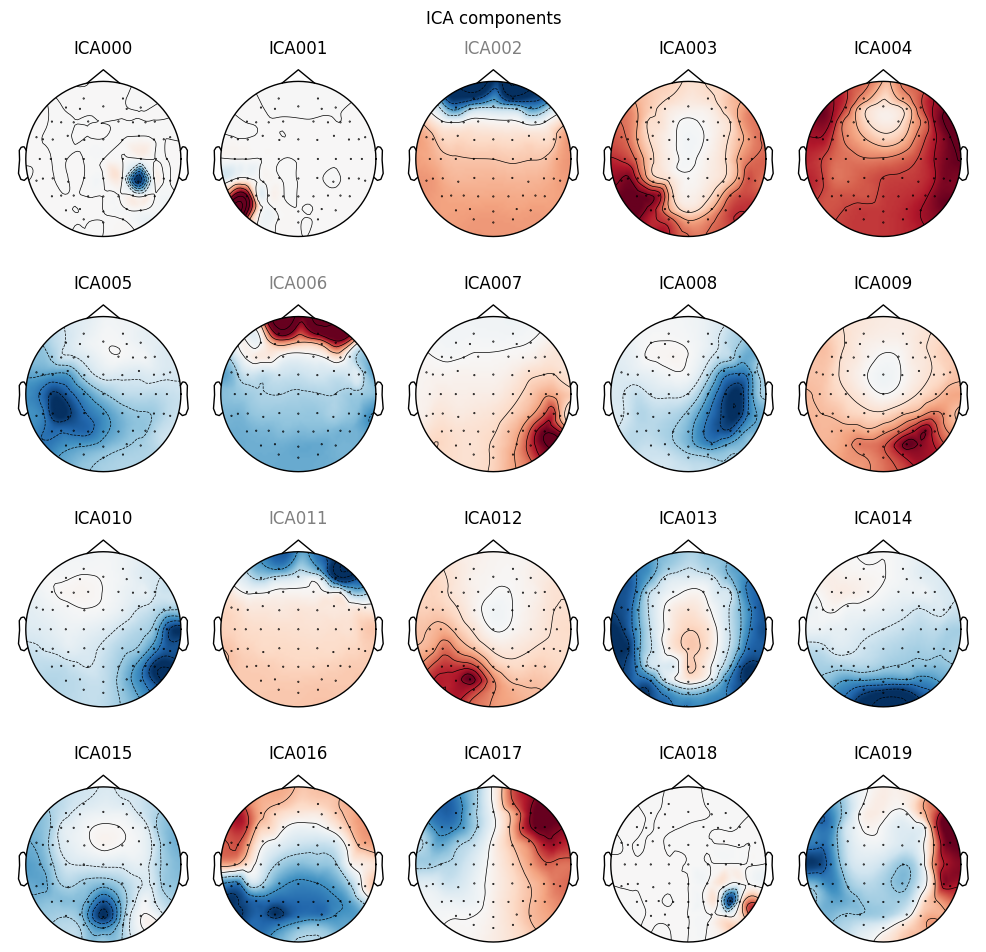

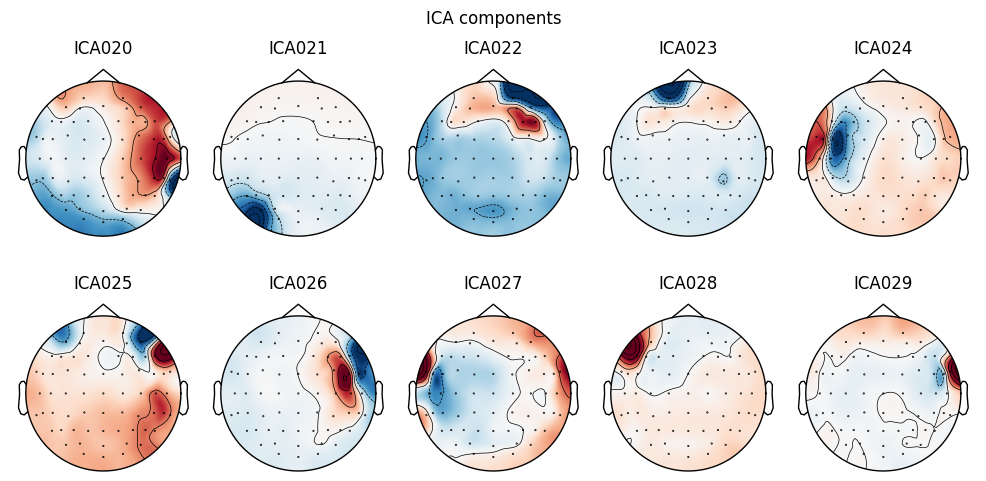

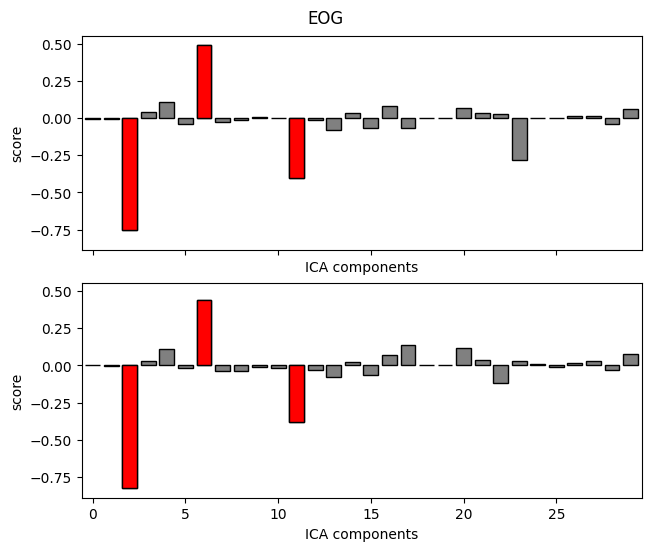

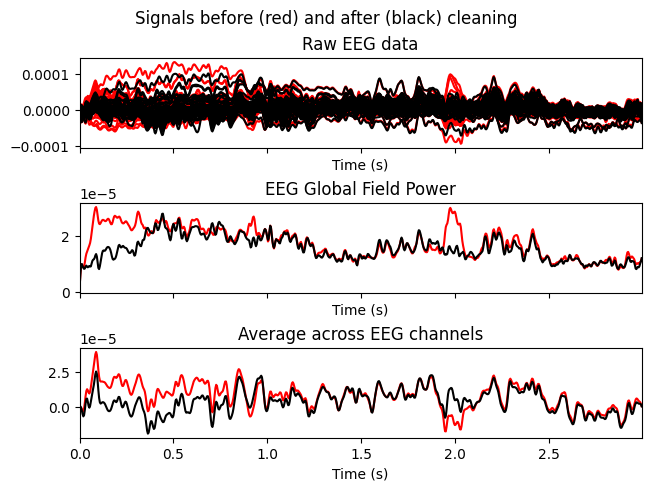

  [ICA] Applying to 0.1 Hz filtered raw...
  [ICA] Done.


<RawArray | 64 x 5342390 (21369.6 s), ~2.55 GiB, data loaded>

In [24]:
run_ica(raw, n_components=30)

In [25]:
rereference_raw(raw)

  [reref] Applying average reference...
  [reref] Done.


<RawArray | 64 x 5342390 (21369.6 s), ~2.55 GiB, data loaded>

In [26]:
epochs = epoch_raw(raw, events, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0), reject_thresh=200e-6)

  [epoch] Epoching -0.2 to 0.8 s, baseline (-0.2, 0.0)...
  [epoch] 67200 epochs -> 64451 kept, 2749 dropped (4.1%)


In [27]:
def plot_all_channel_averages(epochs: mne.Epochs, subject_id: int, split: str):
    """
    Plot grand average ERP waveform for every EEG channel in a grid layout.
    Useful for quickly scanning all channels for artifacts, polarity issues,
    or unexpected noise before deeper analysis.
    """
    evoked = epochs.average()
    times_ms = evoked.times * 1000
    ch_names = evoked.ch_names
    data_uv = evoked.data * 1e6    # convert V -> µV

    n_ch = len(ch_names)
    n_cols = 8
    n_rows = int(np.ceil(n_ch / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2))
    axes = axes.flatten()

    for i, (ax, ch_name) in enumerate(zip(axes, ch_names)):
        ax.plot(times_ms, data_uv[i], linewidth=0.8, color='steelblue')
        ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
        ax.axhline(0, color='k', linewidth=0.3)
        ax.set_xlim(-200, 800)
        ax.set_title(ch_name, fontsize=7, pad=2)
        ax.tick_params(labelsize=5)
        ax.set_xlabel('')
        ax.set_ylabel('')

    # Hide any unused axes (if n_ch not divisible by n_cols)
    for ax in axes[n_ch:]:
        ax.set_visible(False)

    fig.supxlabel('Time (ms)', fontsize=9)
    fig.supylabel('Amplitude (µV)', fontsize=9)
    fig.suptitle(
        f"Sub-{subject_id:02d} {split.upper()} — Grand Average, All Channels",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

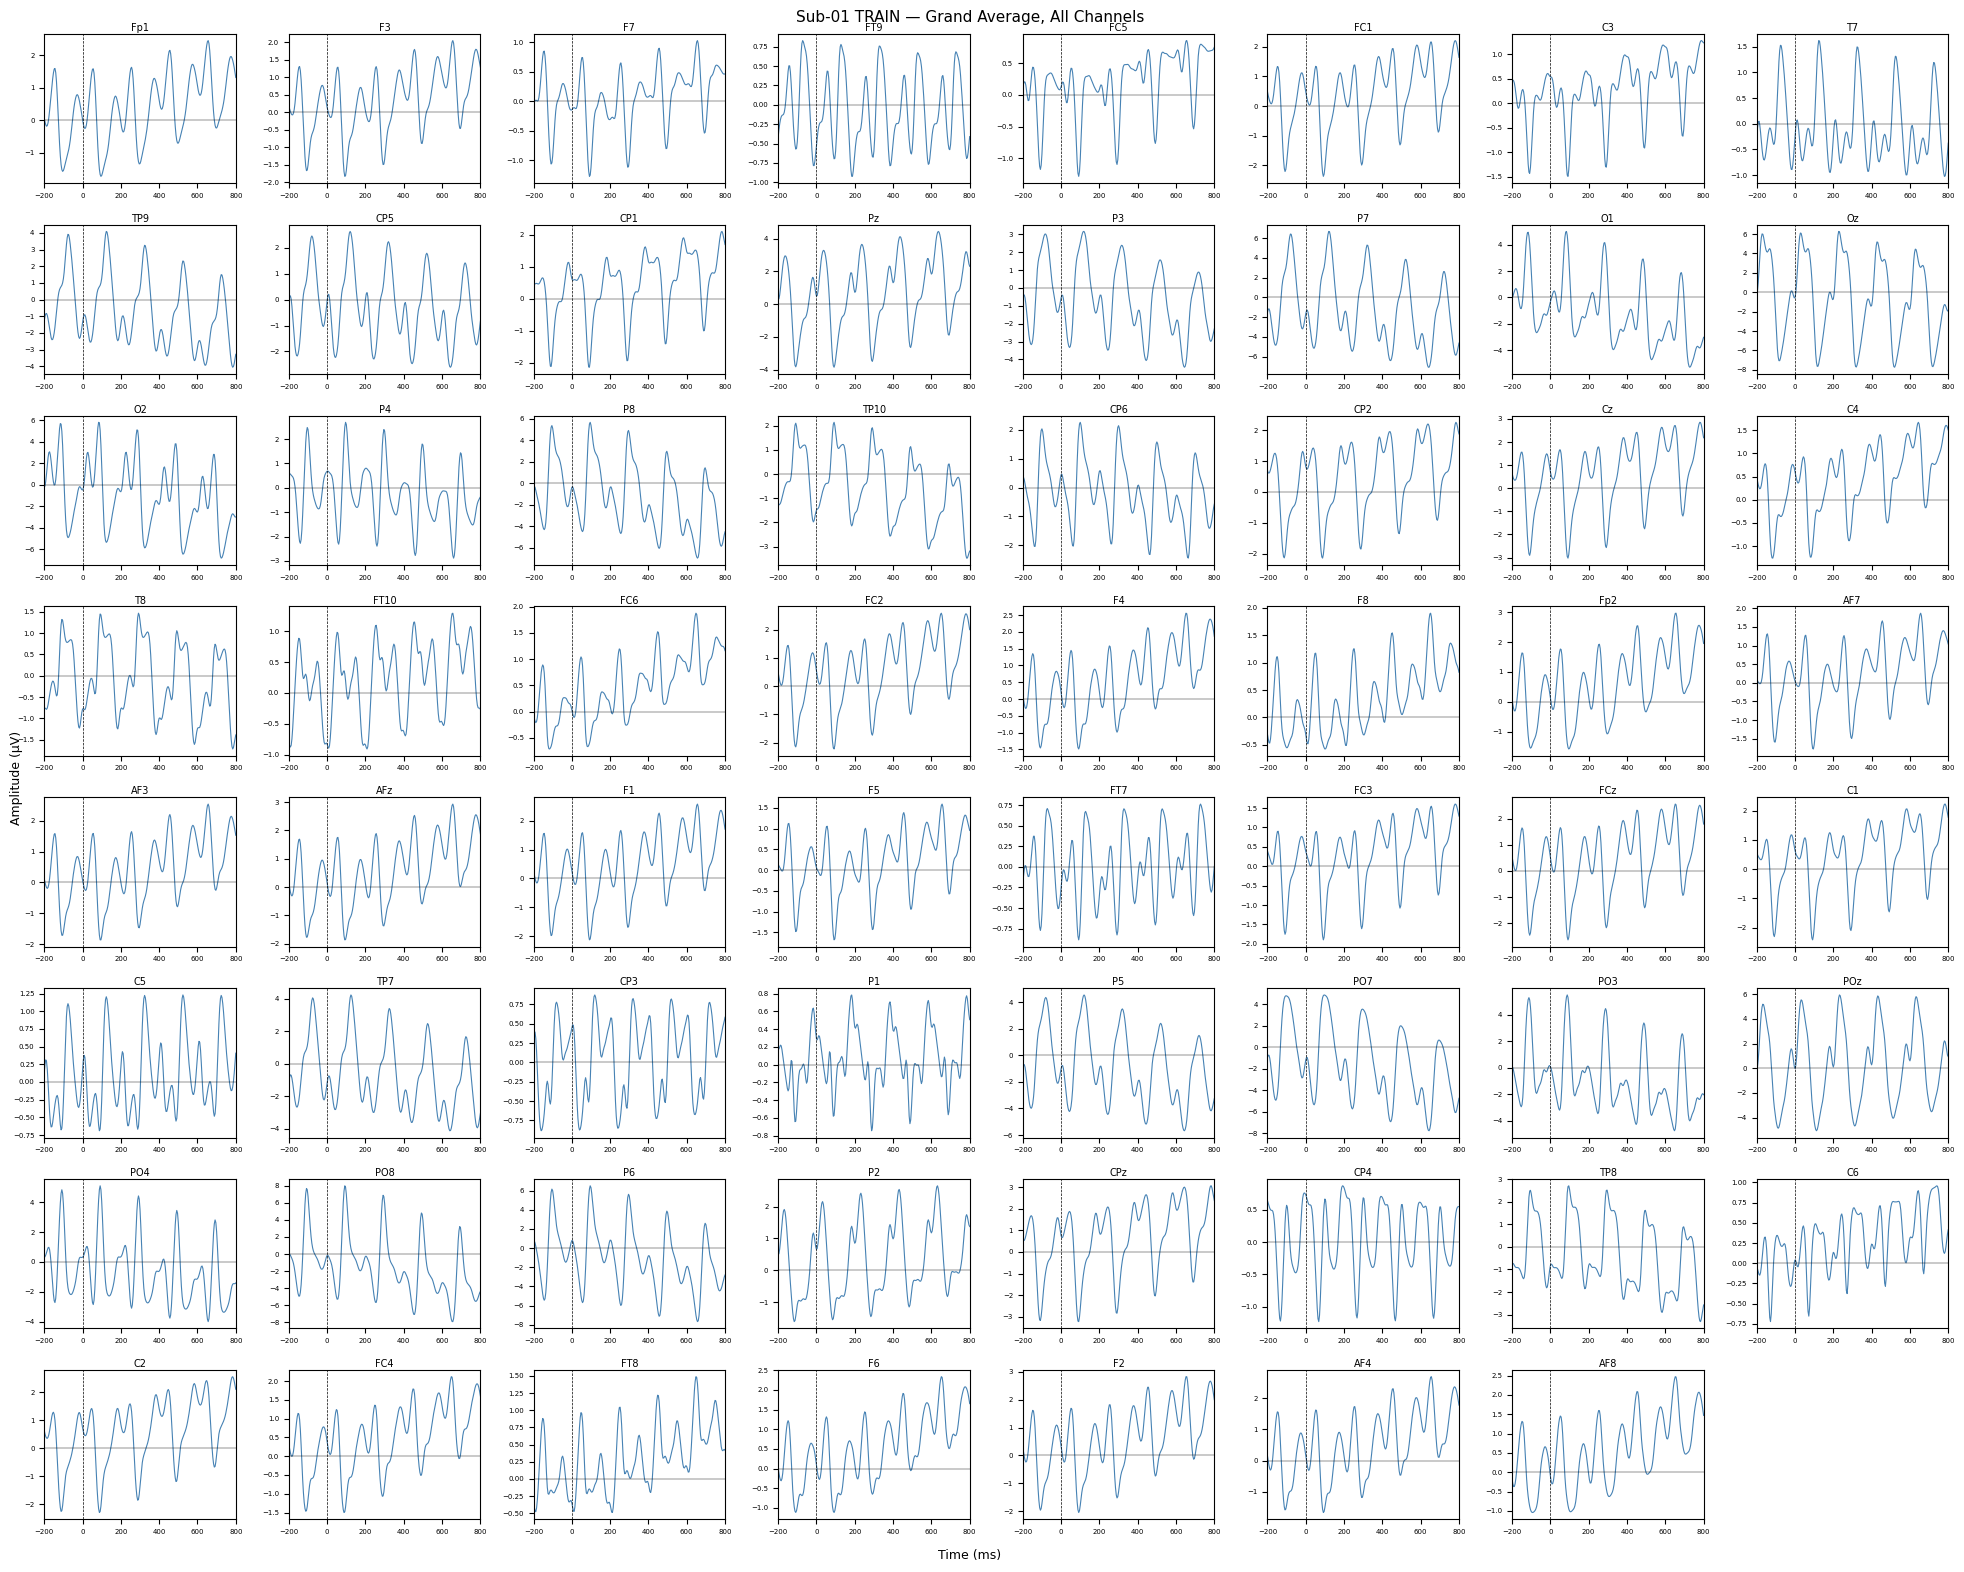

In [28]:
plot_all_channel_averages(epochs, subject_id=1, split='train')

In [41]:
epochs.apply_baseline((-0.2, 0))

<Epochs | 63421 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~7.47 GiB, data loaded,
 '1': 4
 '2': 3
 '3': 4
 '4': 4
 '5': 4
 '6': 4
 '7': 4
 '8': 4
 '9': 4
 '10': 4
 and 16531 more events ...>

In [56]:
split_data['test']['raw_eeg'].get_data()[1, :50] * 1e6  # convert V -> µV for easier interpretation

array([10.95809375, 10.94054616, 11.41471278, 12.53279998, 14.17006721,
       15.40373967, 15.44570132, 14.40009334, 12.49961213,  9.82779953,
        6.89773206,  4.52461011,  3.34319897,  3.79333302,  5.68618483,
        7.69576632,  8.69826825,  9.03472438,  9.43374151,  9.94872537,
       10.32256552, 10.43853225, 10.53847727, 10.85509698, 10.2401681 ,
        7.52753826,  4.36706319,  2.76183941,  2.04925432,  1.11617985,
        0.40206889,  0.4570005 ,  0.71449243,  0.51422093,  0.03662108,
       -0.39367656, -0.54779025,  0.14419548,  1.62315286,  2.83431862,
        3.10287317,  2.54630912,  1.66664038,  1.13754214,  1.16424501,
        1.35269096,  1.3710015 ,  1.22833189,  1.25045712,  1.6426078 ])

In [30]:
pre_stim = epochs.get_data(picks='eeg')[:, :, epochs.times < 0]
print(f"Pre-stim mean: {pre_stim.mean() * 1e6:.4f} µV")
print(f"Pre-stim std:  {pre_stim.std() * 1e6:.4f} µV")



Pre-stim mean: -0.0000 µV
Pre-stim std:  8.4863 µV


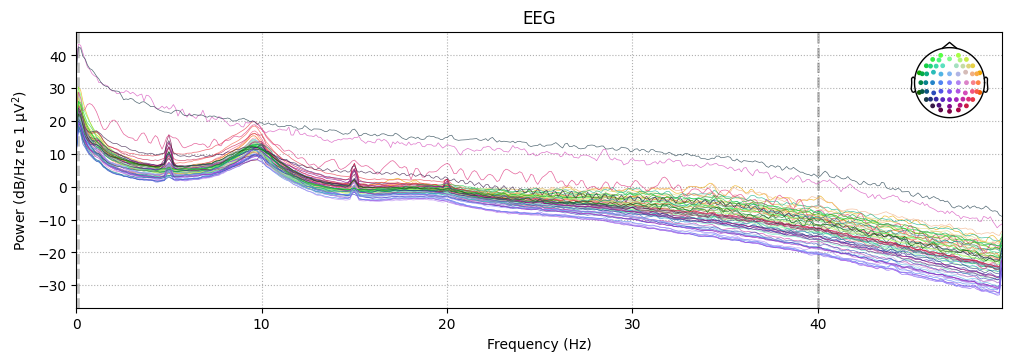

In [29]:
raw.plot_psd(fmax=50)

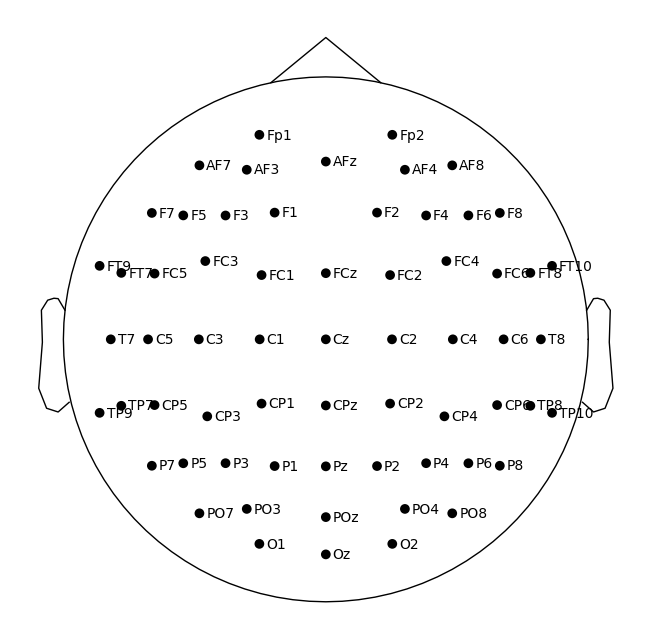

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, P7, ...
 chs: 63 EEG, 1 Stimulus
 custom_ref_applied: True
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.1 Hz
 lowpass: 40.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 250.0 Hz
>


In [73]:
#plot montage
raw.plot_sensors(show_names=True)
print(raw.info)

In [ ]:
# Compute average power in 1-7 Hz band and plot topography
from mne.viz import plot_topomap

psds = epochs.compute_psd(fmin=0, fmax=7)
band_power = psds.get_data().mean(axis=(0, 2))  # average across epochs and freq

fig, ax = plt.subplots()
plot_topomap(band_power, epochs.info, axes=ax, show=True)
ax.set_title('Mean 0-7 Hz power — if artifact: irregular blobs\nif neural: smooth gradient')